# Q1


In [1]:
import numpy as np

# 1. Define the function f(x) = x³/(eˣ - 1)
def f(x):
    """
    Planck integrand: f(x) = x³ / (eˣ - 1)
    Handles x=0 using the limit: lim_{x→0} f(x) = 0
    """
    x = np.asarray(x, dtype=np.float64)
    result = np.zeros_like(x)
    
    # For x > threshold, compute directly
    mask = x > 1e-8
    if np.any(mask):
        result[mask] = x[mask]**3 / (np.exp(x[mask]) - 1)
    # For x ≈ 0: f(x) ≈ x² → 0 (already initialized)
    return result

# 2. Simpson's 3/8 rule implementation
def simp38(f, a, b, n):
    """
    Simpson's 3/8 rule: ∫[a,b] f(x)dx ≈ (3h/8)[f₀ + 3f₁ + 3f₂ + 2f₃ + ... + fₙ]
    n must be divisible by 3.
    """
    if n % 3 != 0:
        raise ValueError("n must be divisible by 3 for Simpson's 3/8 rule")
    
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    
    # Apply coefficient pattern: 1, 3, 3, 2, 3, 3, 2, ..., 3, 3, 1
    result = y[0] + y[-1]  # endpoints
    
    for i in range(1, n):
        if i % 3 == 0:
            result += 2 * y[i]   # every 3rd interior point
        else:
            result += 3 * y[i]   # other interior points
    
    return result * 3 * h / 8

# 3. Known exact value and integration setup
exact = np.pi**4 / 15
xmax = 12  # Upper limit where f(x) ≈ 0 (check: f(12) ≈ 8×10⁻⁴)

print(f"Known exact value: π⁴/15 = {exact:.10f}\n")
print("Convergence study (Simpson's 3/8 rule, xmax=12):")
print(f"{'n':>8} {'Result':>15} {'Abs. Error':>15} {'Rel. Error (%)':>15}")
print("-" * 58)

# 4. Convergence study with different step sizes
for n in [30, 60, 120, 240, 480, 960]:
    result = simp38(f, 0, xmax, n)
    abs_err = abs(result - exact)
    rel_err = abs_err / exact * 100
    print(f"{n:8d} {result:15.10f} {abs_err:15.2e} {rel_err:15.6f}")

# 5. Final result with refined parameters
n_final = 960
result_final = simp38(f, 0, xmax, n_final)
abs_error = abs(result_final - exact)
rel_error = abs_error / exact * 100

print(f"\n{'='*58}")
print(f"FINAL RESULTS (n={n_final}, xmax={xmax}):")
print(f"  Numerical integral:  {result_final:.10f}")
print(f"  Exact value (π⁴/15): {exact:.10f}")
print(f"  Absolute error:      {abs_error:.2e}")
print(f"  Relative error:      {rel_error:.6f}%")

Known exact value: π⁴/15 = 6.4939394023

Convergence study (Simpson's 3/8 rule, xmax=12):
       n          Result      Abs. Error  Rel. Error (%)
----------------------------------------------------------
      30    6.4811473727        1.28e-02        0.196984
      60    6.4802485393        1.37e-02        0.210825
     120    6.4801923630        1.37e-02        0.211690
     240    6.4801888520        1.38e-02        0.211744
     480    6.4801886326        1.38e-02        0.211748
     960    6.4801886189        1.38e-02        0.211748

FINAL RESULTS (n=960, xmax=12):
  Numerical integral:  6.4801886189
  Exact value (π⁴/15): 6.4939394023
  Absolute error:      1.38e-02
  Relative error:      0.211748%


# Q2


In [2]:

# Parameters
epsilon = 1.0
sigma = 1.0

# 1. Force function F(r)
def force(r):
    return 24 * epsilon * (2 * (sigma**12) / r**13 - (sigma**6) / r**7)

# Derivative of the force F'(r) (required for Newton's method)
def dforce_dr(r):
    return 24 * epsilon * (-26 * (sigma**12) / r**14 + 7 * (sigma**6) / r**8)

# 2. Newton-Raphson root finder
def newton_raphson(f, df, x0, tol=1e-8, max_iter=100):
    x = float(x0)
    for i in range(max_iter):
        fx = f(x)
        if abs(fx) < tol:
            return x, i + 1
        dfx = df(x)
        if dfx == 0:
            raise ZeroDivisionError("Derivative is zero. Method fails.")
        x = x - fx / dfx
    return x, max_iter

# 4. Initial guess around r ≈ 1
r_guess = 1.0

# Run solver
r_star, iterations = newton_raphson(force, dforce_dr, r_guess)

# 5. Print converged value
print(f"Converged equilibrium distance: r* = {r_star:.8f}")
print(f"Converged in {iterations} iterations.")

# 6. Compare to analytical result
r_analytical = 2**(1/6)
print(f"\nAnalytical result: r* = {r_analytical:.8f}")
print(f"Absolute error:    |r_num - r_ana| = {abs(r_star - r_analytical):.2e}")

Converged equilibrium distance: r* = 1.12246205
Converged in 7 iterations.

Analytical result: r* = 1.12246205
Absolute error:    |r_num - r_ana| = 1.33e-11


# Q3

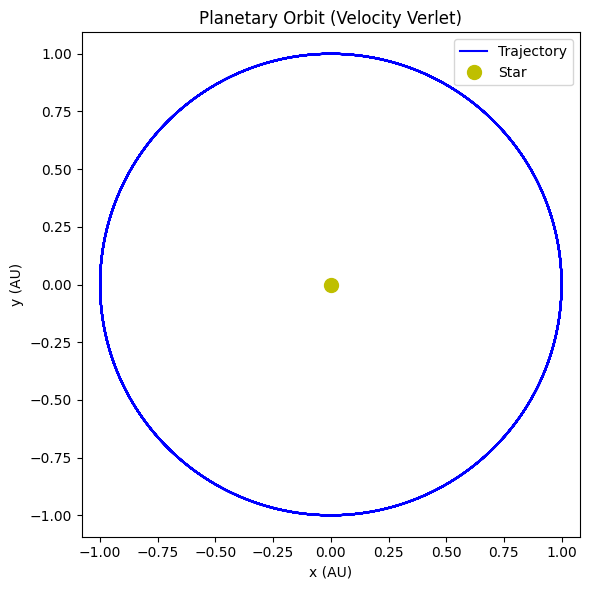

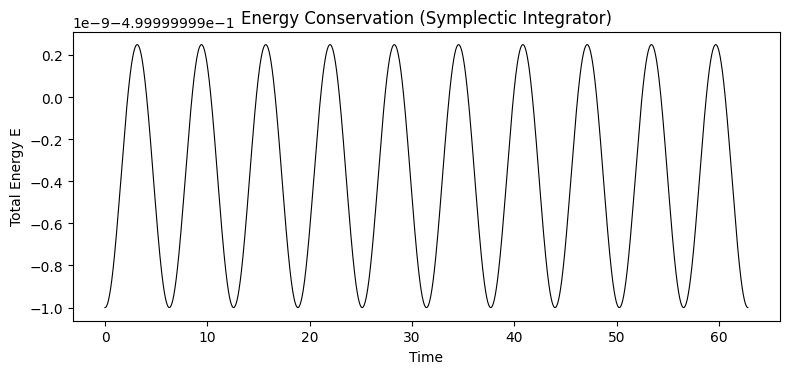

Initial Energy (E₀): -0.50000000
Theoretical circular orbit energy: -0.50000000
Min Energy during sim: -0.50000000
Max Energy during sim: -0.50000000
Energy drift over 10 periods: -1.02e-14


In [3]:
import matplotlib.pyplot as plt

# === Parameters ===
GM = 1.0          # Gravitational parameter
m = 1.0           # Planet mass
r0 = 1.0          # Initial orbital radius (AU)
v0 = np.sqrt(GM / r0)  # Circular orbit velocity = 1.0
dt = 0.01         # Timestep
n_periods = 10    # Number of orbital periods to simulate
T_orbital = 2 * np.pi * r0 / v0  # Kepler's 3rd law: T = 2π
t_max = n_periods * T_orbital
steps = int(t_max / dt)

# === Initial Conditions (Circular Orbit) ===
# Position: (1, 0), Velocity: (0, 1) -> perpendicular for circular orbit
r_vec = np.array([r0, 0.0])
v_vec = np.array([0.0, v0])
a_vec = -GM * r_vec / (np.linalg.norm(r_vec)**3)

# Storage arrays
t_vals = np.zeros(steps + 1)
E_vals = np.zeros(steps + 1)
traj = np.zeros((steps + 1, 2))

# Initial energy and storage
traj[0] = r_vec
E_vals[0] = 0.5 * m * np.dot(v_vec, v_vec) - GM * m / np.linalg.norm(r_vec)
t_vals[0] = 0.0

# === Velocity Verlet Integration ===
for i in range(steps):
    # 1. Update position
    r_vec = r_vec + v_vec * dt + 0.5 * a_vec * dt**2
    
    # 2. Compute new acceleration
    a_new = -GM * r_vec / (np.linalg.norm(r_vec)**3)
    
    # 3. Update velocity
    v_vec = v_vec + 0.5 * (a_vec + a_new) * dt
    a_vec = a_new  # Update acceleration for next step
    
    # Store results
    t_vals[i+1] = (i + 1) * dt
    traj[i+1] = r_vec
    E_vals[i+1] = 0.5 * m * np.dot(v_vec, v_vec) - GM * m / np.linalg.norm(r_vec)

# === Plot 1: Orbital Trajectory ===
plt.figure(figsize=(6, 6))
plt.plot(traj[:, 0], traj[:, 1], 'b-', label='Trajectory')
plt.plot(0, 0, 'yo', markersize=10, label='Star')
plt.axis('equal')
plt.legend()
plt.title('Planetary Orbit (Velocity Verlet)')
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.tight_layout()
plt.show()

# === Plot 2: Energy Conservation ===
plt.figure(figsize=(8, 4))
plt.plot(t_vals, E_vals, 'k-', linewidth=0.8)
plt.xlabel('Time')
plt.ylabel('Total Energy E')
plt.title('Energy Conservation (Symplectic Integrator)')
plt.tight_layout()
plt.show()

# === Energy Conservation Analysis ===
print(f"Initial Energy (E₀): {E_vals[0]:.8f}")
print(f"Theoretical circular orbit energy: {-GM*m/(2*r0):.8f}")
print(f"Min Energy during sim: {E_vals.min():.8f}")
print(f"Max Energy during sim: {E_vals.max():.8f}")
print(f"Energy drift over {n_periods} periods: {E_vals[-1] - E_vals[0]:.2e}")

# Q4

The system is already provided in a form that is very close to first-order. We define a state vector $\mathbf{u}$ containing our four variables:
$$ \mathbf{u} = \begin{bmatrix} x \\ y \\ v_x \\ v_y \end{bmatrix} $$

The derivative of this vector with respect to time, $\frac{d\mathbf{u}}{dt}$, is defined by the system of equations given in the problem:

$$
\frac{d}{dt} \begin{bmatrix} x \\ y \\ v_x \\ v_y \end{bmatrix} = \begin{bmatrix} v_x \\ v_y \\ -\frac{C_d}{m} |\mathbf{v}| v_x \\ -g - \frac{C_d}{m} |\mathbf{v}| v_y \end{bmatrix}
$$

where $|\mathbf{v}| = \sqrt{v_x^2 + v_y^2}$.

In [4]:
# --- Parameters ---
g = 9.81            # Acceleration due to gravity (m/s^2)
m = 1.0             # Mass of projectile (kg)
Cd = 0.05           # Drag coefficient (kg/m) - Adjust to see effects
v0 = 50.0           # Initial speed (m/s)
theta0_deg = 45.0   # Launch angle (degrees)
dt = 0.01           # Time step (s)

# Convert angle to radians and calculate initial velocity components
theta0_rad = np.radians(theta0_deg)
vx0 = v0 * np.cos(theta0_rad)
vy0 = v0 * np.sin(theta0_rad)

# Initial state vector: [x, y, vx, vy]
u = np.array([0.0, 0.0, vx0, vy0])
t = 0.0

# --- Define the Derivative Function (The ODE System) ---
def derivatives(t, u):
    x, y, vx, vy = u
    v_mag = np.sqrt(vx**2 + vy**2)
    
    dxdt = vx
    dydt = vy
    dvxdt = -(Cd / m) * v_mag * vx
    dvydt = -g - (Cd / m) * v_mag * vy
    
    return np.array([dxdt, dydt, dvxdt, dvydt])

# --- Runge-Kutta 4 Integration Loop ---
# We store history just to plot or inspect later (optional)
history = [u.copy()]
time_history = [t]

print(f"Starting simulation with v0={v0} m/s, theta={theta0_deg} deg, Cd={Cd}")

while True:
    # RK4 Steps
    k1 = dt * derivatives(t, u)
    k2 = dt * derivatives(t + dt/2, u + k1/2)
    k3 = dt * derivatives(t + dt/2, u + k2/2)
    k4 = dt * derivatives(t + dt, u + k3)
    
    # Update state
    u_new = u + (k1 + 2*k2 + 2*k3 + k4) / 6
    t_new = t + dt
    
    # Check for ground impact (y < 0)
    # We check if the NEW y position is below zero. 
    # Since we started at y=0, we must ensure we have actually flown up first.
    if u_new[1] < 0 and t_new > 0.1: 
        # Linear interpolation to find exact range where y=0
        # y_old is u[1], y_new is u_new[1]
        # fraction = (0 - y_old) / (y_new - y_old)
        fraction = -u[1] / (u_new[1] - u[1])
        x_final = u[0] + fraction * (u_new[0] - u[0])
        print(f"Impact detected at t = {t_new:.4f} s")
        print(f"Final Range (x): {x_final:.4f} meters")
        break
    
    # Update for next iteration
    u = u_new
    t = t_new
    history.append(u.copy())
    time_history.append(t)

# Optional: Calculate range without drag for comparison
# Range = (v0^2 * sin(2*theta)) / g
range_vacuum = (v0**2 * np.sin(2 * theta0_rad)) / g
print(f"Theoretical Range (Vacuum/No Drag): {range_vacuum:.4f} meters")

Starting simulation with v0=50.0 m/s, theta=45.0 deg, Cd=0.05
Impact detected at t = 3.4900 s
Final Range (x): 34.0834 meters
Theoretical Range (Vacuum/No Drag): 254.8420 meters


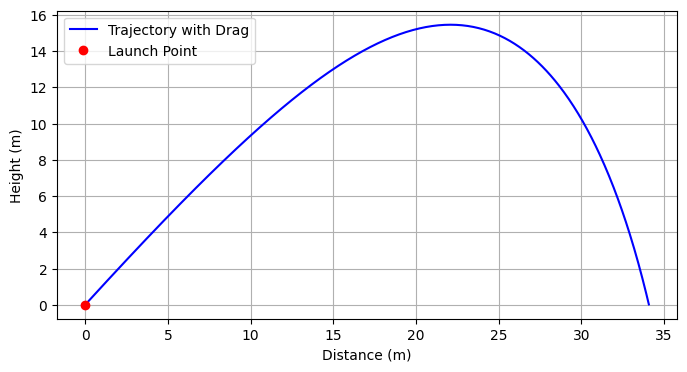

In [5]:
# plot trajectory
history = np.array(history)
plt.figure(figsize=(8, 4))
plt.plot(history[:, 0], history[:, 1], 'b-', label='Trajectory with Drag')
plt.plot(0, 0, 'ro', label='Launch Point')
plt.xlabel('Distance (m)')
plt.ylabel('Height (m)')
plt.legend()
plt.grid(True)